<a href="https://colab.research.google.com/github/Mirsha-RG/tallerprograma2/blob/projects/ejercicio_pvalue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from scipy.stats import norm, binomtest, binom
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Ho: P = 0.07
#Ha: P < 0.07
"""
Un vecino afirma que sus elotes con chile se venden un 70% mas que sin chile, yo creo que son menos
porque la mayoria de sus clientes son niños.
Para probarlo lo espio, analiso 57 clientes
cuento que 35 si pidieron chile """

'\nUn vecino afirma que sus elotes con chile se venden un 70% mas que sin chile, yo creo que son menos\nporque la mayoria de sus clientes son niños.\nPara probarlo lo espio, analiso 57 clientes\ncuento que 35 si pidieron chile '

In [4]:
# Datos
n_clientes = 157
con_chile = 99
p_afirmada = 0.7
alpha = 0.05

media_esperada = n_clientes * p_afirmada

resultado = binom.cdf(con_chile, n_clientes, p_afirmada)

if binomtest(con_chile, n_clientes, p_afirmada, alternative='less').pvalue <= alpha:
    print(f"{resultado} reject dado que ... (acepto Ha) ")
else:
    print(f"{resultado} no reject dado que ... (acepto Ho)")


0.03686232232925259 reject (acepto Ha) 


In [7]:
n_clientes = 157
p_verdadera = 0.7
con_chile_observado = 99
simulaciones = 10000

# Simulamos 10,000 muestras con distribución binomial
resultados = np.random.binomial(n_clientes, p_verdadera, simulaciones)

# Calculamos la proporción de simulaciones donde obtenemos <= observado
p_value_simulado = np.mean(resultados <= con_chile_observado)
print(resultados)

[110 110 107 ... 111 124 111]


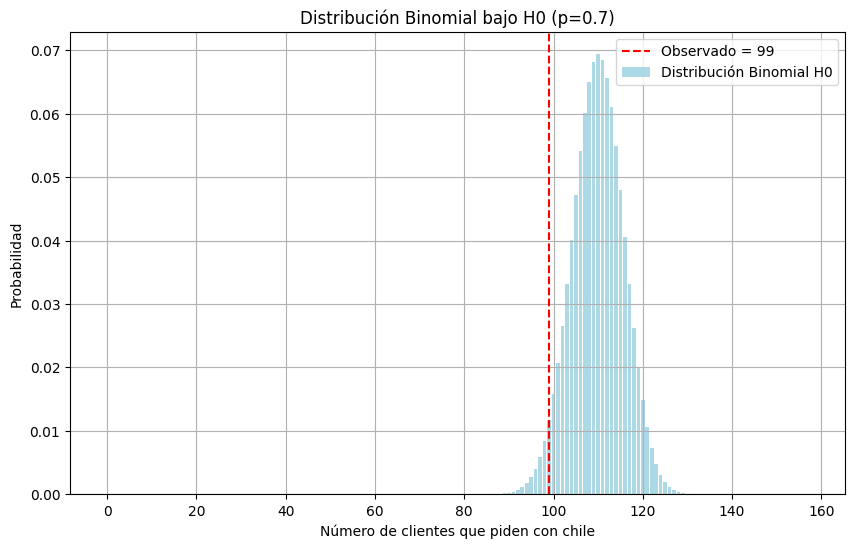

In [6]:

x = np.arange(0, n_clientes + 1)

# Probabilidades bajo H0
pmf = binom.pmf(x, n_clientes, p_afirmada)

plt.figure(figsize=(10,6))
plt.bar(x, pmf, color='lightblue', label='Distribución Binomial H0')

# Marca el valor observado
plt.axvline(con_chile, color='red', linestyle='--', label=f'Observado = {con_chile}')

plt.title('Distribución Binomial bajo H0 (p=0.7)')
plt.xlabel('Número de clientes que piden con chile')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
mu = 15
x_nula = 20
std = 5
trials = 1000
alpha = 0.05

pop = np.random.normal(loc=mu, scale=std, size=trials)
mayores = []

for i in range (len(pop)):
  if pop[1] > x_nula:
    mayores.append(1)

p_value = len(mayores)/(trials)
print(f'p simulado es {p_value}')

if p_value < alpha:
  print(f'No reject, porque es poco probable ({p_value*100}%) que mis datos tengan media {x_nula}')

else:
  print(f'No reject, porque es ({p_value*100}%)de ue las iguanas midan {x_nula}cm o mas, es decir mas probable que alpha')


p simulado es 0.0
No reject, porque es poco probable (0.0%) que mis datos tengan media 20


In [10]:
pformula = 1 - (norm.cdf(x_nula, loc=mu, scale=std))
print(f'p-value con teoria es {pformula}')

p-value con teoria es 0.15865525393145707
